In [1]:
from Config import *
from Dataset import *
from Experiments import *
from Metric import *
from Model import *
from Utils import *
from FID import *
from Train import *

import gc


class set_args:
    def __init__(self):
        self.seed = 5
        self.state = 'train'
        self.epochs = 150 # training epochs
        self.batch_size = 80
        self.dataset = 'Imagenet'#'MNIST'#'CIFAR10' 
        self.split_class= [0]

        #Load different model if TRUE
        self.load_different_model = False
        self.load_trained_model = False
        self.load_training_checkpoint = 30 #30,#200
        self.load_rd_training_checkpoint = 150

        self.sample_dir = 'Result'
        self.checkpoint_dir = 'Result'
        self.M = [0]
        self.I = [0]

        #Reduce training sample
        self.rd = 0.05
        self.training_anchor_num = 10 # training_anchor_num=200
        self.testing_anchor_num = 100 # testing_anchor_num=2500
        self.metric = 'L2'
        

        self.save_weight_dir = 'Result/CheckpointsMNIST/'

        
    
directory_init()

args = set_args()
seed_everything(args.seed) 


"""Merge both these"""
model_config = set_config(args, custom_dataset=args.dataset) 

model, sampler, trainer = model_init(args, model_config)

# FID

block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
InceptionV3_model = InceptionV3([block_idx])
InceptionV3_model=InceptionV3_model.cuda()



1.13.1
Config : Imagenet
Config : haha
loading model : c0_ckpt_30_.pt ......


c:\Users\user\Desktop\DDPM_XAI\Utils.py:799: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(


model load weight done.
update Sampler ...... done
update Trainer ...... done


c:\Users\user\.conda\envs\FID\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\.conda\envs\FID\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
import torch
from diffusers import ConsistencyModelPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

# 加載 Consistency Model
model_id = "openai/diffusers-cd_imagenet64_lpips"
pipe = ConsistencyModelPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe.to(device)


c:\Users\user\.conda\envs\FID\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  6.22it/s]


ConsistencyModelPipeline {
  "_class_name": "ConsistencyModelPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "openai/diffusers-cd_imagenet64_lpips",
  "scheduler": [
    "diffusers",
    "CMStochasticIterativeScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

100%|██████████| 2/2 [00:00<00:00, 40.55it/s]


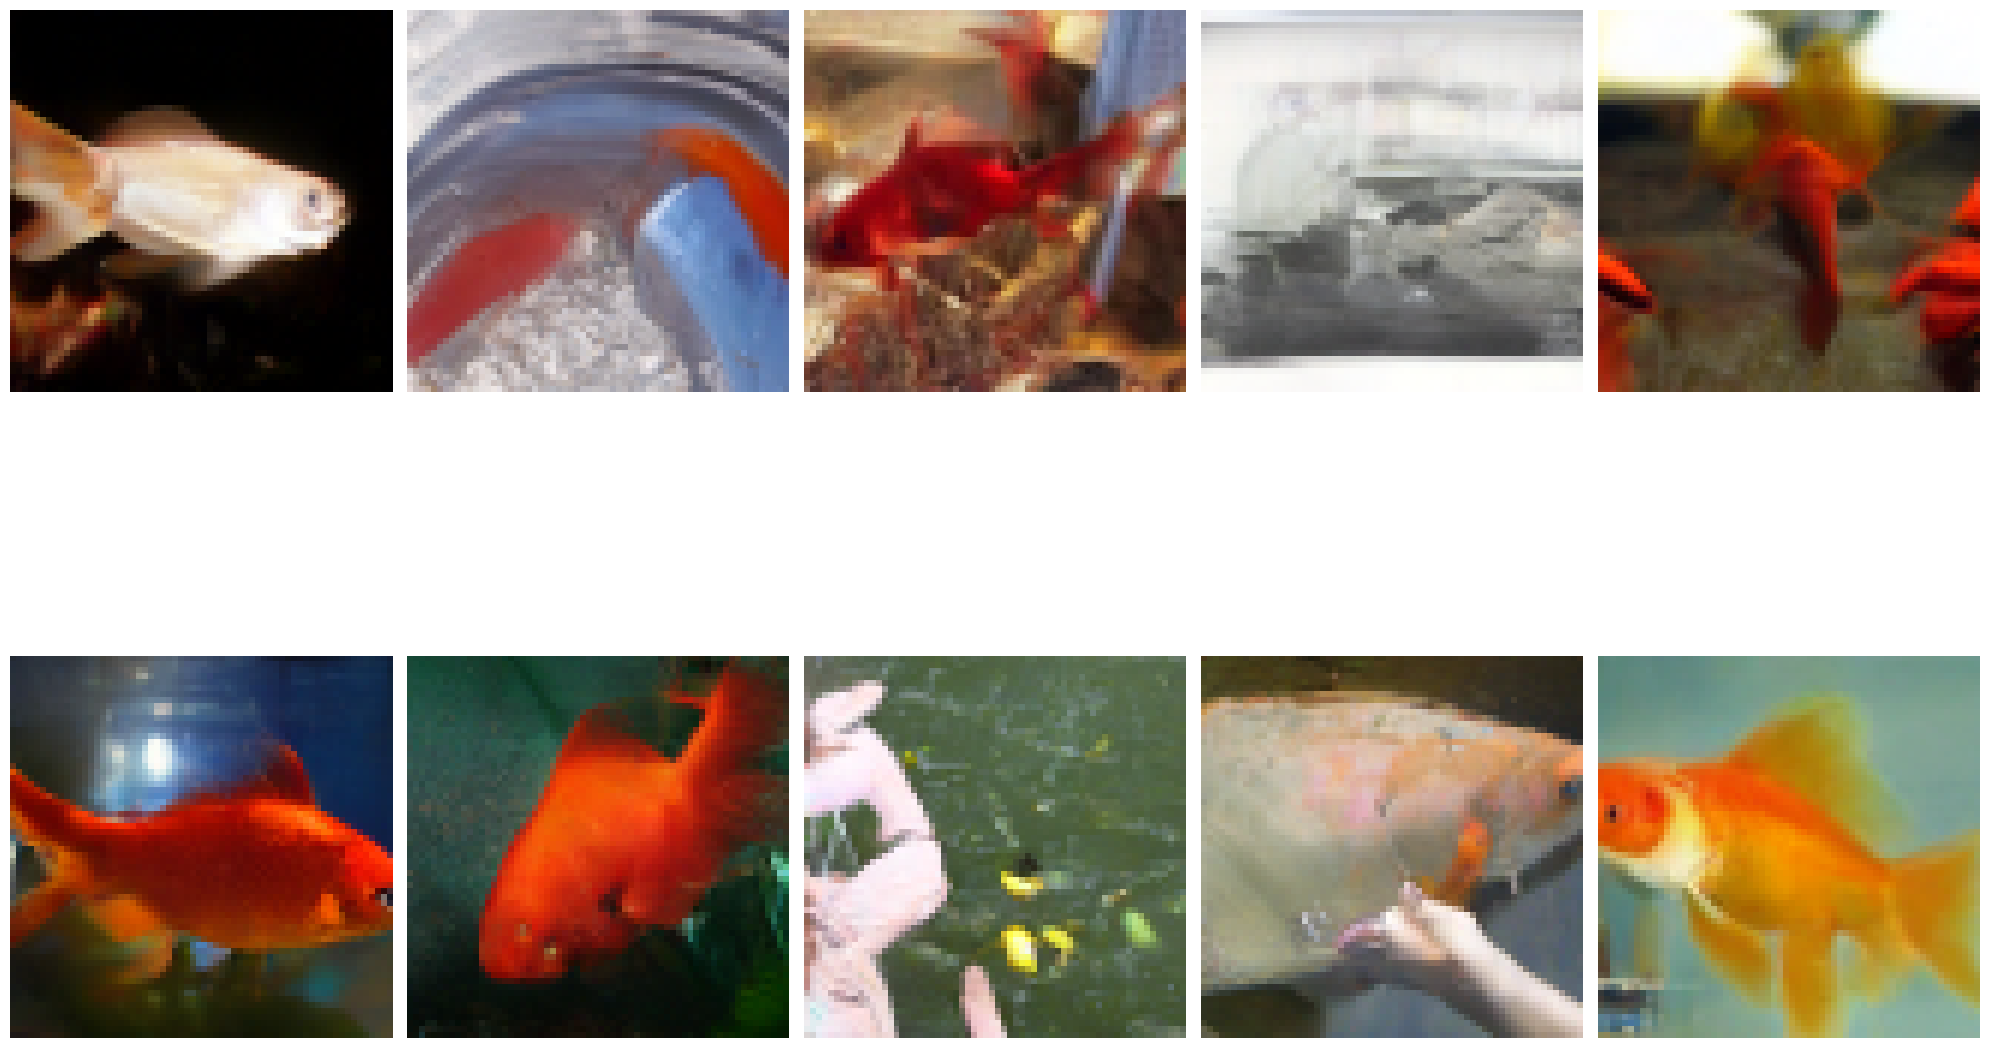

In [47]:
num_samples = 80
images = []

for _ in range(num_samples):
    image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
    images.append(image)

import matplotlib.pyplot as plt

# 設定行數與列數（可以根據需要調整）
rows, cols = 2, 5  # 8 行 x 10 列

fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis("off")  # 隱藏座標軸

plt.tight_layout()
plt.show()


In [4]:
from diffusers import ConsistencyModelPipeline
import torch
from PIL import Image
import torchvision.transforms as T

# Load your image (must be 64x64 for this model)
image = images[0]

# Convert to tensor in range [-1, 1]
preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])
image_tensor = preprocess(image).unsqueeze(0).to("cuda").half()


In [5]:
t = pipe.scheduler.timesteps[0].unsqueeze(0)
noise = torch.randn_like(image_tensor)
class_label = torch.tensor([1], dtype=torch.long).to(image_tensor.device)


noisy_image = pipe.scheduler.add_noise(image_tensor, noise, t)


In [ ]:
pipe.unet()

UNet2DModel(
  (conv_in): Conv2d(3, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=192, out_features=768, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=768, out_features=768, bias=True)
  )
  (class_embedding): Embedding(1000, 768)
  (down_blocks): ModuleList(
    (0): ResnetDownsampleBlock2D(
      (resnets): ModuleList(
        (0-2): 3 x ResnetBlock2D(
          (norm1): GroupNorm(32, 192, eps=1e-05, affine=True)
          (conv1): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=768, out_features=384, bias=True)
          (norm2): GroupNorm(32, 192, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(


In [6]:
noise_pred = pipe.unet(noisy_image, t, class_label).sample

In [7]:
x0_pred = pipe.scheduler.predict_start_from_noise(noisy_image, t, noise_pred)

AttributeError: 'CMStochasticIterativeScheduler' object has no attribute 'predict_start_from_noise'

In [ ]:
t_index = 0  # e.g. 你要的 timestep index
t = pipe.scheduler.timesteps[t_index].unsqueeze(0).to('cuda')
sigma_t = pipe.scheduler.sigmas[t_index]

# 已知 noisy image = x_t
noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

# 預測 noise
pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
).sample

# 還原 x_0
#x0_pred = noisy_image - sigma_t * pred_noise

x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


IndexError: index 3 is out of bounds for dimension 0 with size 3

In [9]:
x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


IndexError: index 3 is out of bounds for dimension 0 with size 3

In [ ]:
o_img = pipe.unet(noisy_image, t, class_label)

In [72]:
x0_pred.shape

torch.Size([1, 3, 64, 64])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-483.0..425.0].


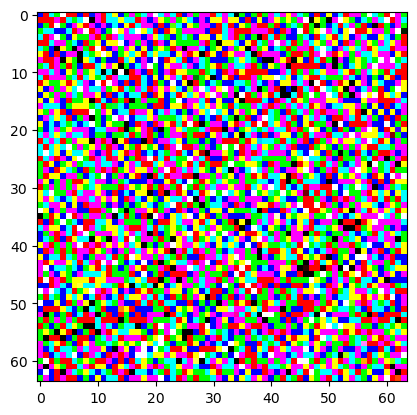

In [73]:
plt.imshow(x0_pred[0].permute(1, 2, 0).cpu().detach().to(torch.float32).numpy())


In [5]:
pipe.unet()

TypeError: UNet2DModel.forward() missing 2 required positional arguments: 'sample' and 'timestep'

In [43]:
dt_train = CUSTOM_DATASET(args, split=True)
train_dataset, test_dataset = dt_train.load_dataset(custom_trasform=False)

In [ ]:
features = {}

def hook(module, input, output):
    features["mid_block"] = output

hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

# 正常呼叫 UNet
output = pipe.unet(noisy_image, t, class_label)

mid_block_output = features["mid_block"]

hook_handle.remove()


In [26]:
noisy_image

tensor([[[[  39.9062, -213.1250,  -97.5625,  ...,   41.6250,  -80.5000,
            108.2500],
          [  38.0938,   18.4531,  -41.7812,  ..., -145.8750,  -59.2812,
            111.6875],
          [  34.1250,   86.8750,  126.0625,  ...,   63.8438,   -4.3789,
            -58.2188],
          ...,
          [ -11.5859,  -22.0781,   -3.2559,  ...,  144.2500,  -26.7500,
             47.9062],
          [ -42.4375,   -5.2539,  -21.0469,  ...,   13.5234,   33.5625,
            -43.7500],
          [  -1.7939,  -61.5000,  -65.3125,  ...,   42.0000,  -45.4062,
            -67.3125]],

         [[  -7.2852, -154.0000,   53.4062,  ...,   53.8438,   35.6562,
           -115.3750],
          [-137.7500,    7.3203,   55.0000,  ...,  -47.0312,   58.2812,
             15.9844],
          [   5.1836,   27.7031,   16.0312,  ...,   14.9766,  -93.5000,
             61.5312],
          ...,
          [ -50.9688,   90.6250,  -56.3125,  ...,  -63.8750,  -19.6406,
             58.5938],
          [  41.87

tensor([1095.5067], device='cuda:0', dtype=torch.float64)
tensor([705.0453], device='cuda:0', dtype=torch.float64)


In [ ]:
t_index = 0  # e.g. 你要的 timestep index
t = pipe.scheduler.timesteps[t_index].unsqueeze(0).to('cuda')
sigma_t = pipe.scheduler.sigmas[t_index]

# 已知 noisy image = x_t
noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

# 預測 noise
pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
).sample

# 還原 x_0
#x0_pred = noisy_image - sigma_t * pred_noise

x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


(tensor([[[ 0.4851,  0.4679,  0.3309,  ...,  0.9303,  0.9132,  0.8276],
          [ 0.5878,  0.3481,  0.1083,  ...,  0.5536,  0.5536,  0.4508],
          [ 0.2453,  0.0569, -0.0801,  ...,  0.1254,  0.1597,  0.0569],
          ...,
          [-0.1143, -0.1143,  0.0741,  ...,  0.6563,  0.5878,  0.5022],
          [-0.0287,  0.1939,  0.2967,  ...,  0.6563,  0.5364,  0.4679],
          [ 0.2967,  0.3138,  0.2796,  ...,  0.4679,  0.1254, -0.0801]],
 
         [[ 0.3102,  0.3803,  0.3978,  ...,  1.0105,  0.9580,  0.8880],
          [ 0.3627,  0.1877,  0.0651,  ...,  0.4328,  0.4853,  0.4678],
          [-0.0224, -0.1099, -0.1975,  ..., -0.1800, -0.0049,  0.0126],
          ...,
          [-0.3025, -0.3375, -0.0749,  ...,  0.7304,  0.6429,  0.5378],
          [-0.1975, -0.0924,  0.0476,  ...,  0.7479,  0.6078,  0.5028],
          [ 0.2052,  0.2052,  0.1001,  ...,  0.5378,  0.2052, -0.0224]],
 
         [[ 0.4614,  0.7402,  0.9145,  ...,  1.4548,  1.4548,  1.4025],
          [ 0.6182,  0.5136,

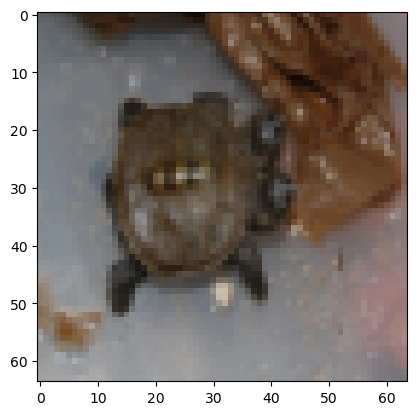

In [46]:
plt.imshow(test_dataset[2][0].permute(1,2,0).numpy())

In [ ]:
train_extrinsic = []
other_extrinsic = []
train_extrinsic = []
other_extrinsic = []



num_samples = 80
gen_images = []
# Convert to tensor in range [-1, 1]
preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])

gen_extrinsic = []
gen_intrinsic = []


features = {}

def hook(module, input, output):
    features["mid_block"] = output

preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])


for i, t in enumerate(pipe.scheduler.timesteps):
    t = t.unsqueeze(0).to('cuda')
    noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

    pred_noise = pipe.unet(
        noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
    ).sample
    
    hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

    # 正常呼叫 UNet
    output = pipe.unet(noisy_image, t, class_label)

    mid_block_output = features["mid_block"]

    hook_handle.remove()
    
    
for _ in range(num_samples):
    image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
    image_tensor = preprocess(image).unsqueeze(0).to("cuda").cpu()

    images.append(image_tensor[0])


gen_dt_mean = 0
for gen_dt in images:
    noisy_image = pipe.scheduler.add_noise(gen_dt, torch.randn_like(gen_dt), t)
    
    pred_noise = pipe.unet(
        noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
    ).sample
    
    hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

    # 正常呼叫 UNet
    output = pipe.unet(noisy_image, t, class_label)

    mid_block_output = features["mid_block"]

    hook_handle.remove

    gen_dt_mean += gen_dt / len(images)

for train_dt, _ in train_dataset:
    curr_ext = 0
    P = np.array(train_dt)
    Q = np.array(gen_dt_mean)
    ext = np.sqrt(np.sum((P - Q) ** 2))
    curr_ext += ext / len(images)
    train_extrinsic.append(curr_ext)

for test_dt, _ in test_dataset:
    curr_ext = 0
    P = np.array(test_dt)
    Q = np.array(gen_dt_mean)
    ext = np.sqrt(np.sum((P - Q) ** 2))
    curr_ext += ext / len(images)
    other_extrinsic.append(curr_ext)
        


100%|██████████| 2/2 [00:00<00:00, 34.32it/s]


RuntimeError: Expected weight to be a vector of size equal to the number of channels in input, but got weight of shape [192] and input of shape [192, 64, 64]

In [112]:
gen_dt_mean

tensor([[[0.3414, 0.3406, 0.3504,  ..., 0.3581, 0.3481, 0.3482],
         [0.3483, 0.3370, 0.3435,  ..., 0.3639, 0.3579, 0.3571],
         [0.3510, 0.3494, 0.3546,  ..., 0.3618, 0.3562, 0.3550],
         ...,
         [0.4275, 0.4281, 0.4270,  ..., 0.3761, 0.3712, 0.3647],
         [0.4150, 0.4166, 0.4164,  ..., 0.3803, 0.3736, 0.3782],
         [0.4148, 0.4133, 0.4222,  ..., 0.3955, 0.3905, 0.3969]],

        [[0.3723, 0.3724, 0.3821,  ..., 0.3980, 0.3869, 0.3857],
         [0.3781, 0.3686, 0.3783,  ..., 0.4035, 0.3933, 0.3920],
         [0.3861, 0.3834, 0.3923,  ..., 0.3966, 0.3933, 0.3908],
         ...,
         [0.4376, 0.4465, 0.4453,  ..., 0.3884, 0.3853, 0.3753],
         [0.4273, 0.4346, 0.4372,  ..., 0.3890, 0.3852, 0.3846],
         [0.4266, 0.4309, 0.4370,  ..., 0.4030, 0.3973, 0.3983]],

        [[0.3675, 0.3648, 0.3744,  ..., 0.3799, 0.3716, 0.3732],
         [0.3732, 0.3604, 0.3731,  ..., 0.3875, 0.3803, 0.3821],
         [0.3734, 0.3698, 0.3853,  ..., 0.3862, 0.3851, 0.

In [ ]:
gen_dt.shape

torch.Size([3, 64, 64])

In [113]:
np.mean(other_extrinsic)

0.32811862521905166

In [114]:
np.mean(train_extrinsic)

0.34148352840313545

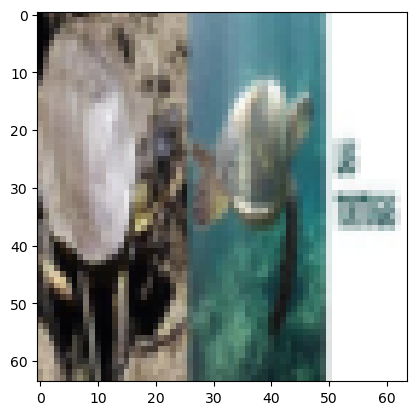

In [88]:
plt.imshow(test_dt.permute(1,2,0).numpy())

In [97]:
test_dt.max()

tensor(1.)

In [94]:
train_dt.max()

tensor(0.8627)

In [98]:
gen_dt.max()

tensor(1.)